In [ ]:
!nvidia-smi

Sat May  9 04:25:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install roboflow ultralytics opencv-python matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.9 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="1qMLQSmFWmPxaBH8uadN")
project = rf.workspace("nicky-kwale").project("number-plate-detection-jobsu")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Number-plate-detection-1 in yolov8:: 100%|██████████| 1440/1440 [00:00<00:00, 3556.26it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os

print("Dataset location:", dataset.location)
print(os.listdir(dataset.location))

Dataset location: /content/Number-plate-detection-1
['README.dataset.txt', 'train', 'test', 'data.yaml', 'valid', 'README.roboflow.txt']


In [ ]:
data_yaml_path = os.path.join(dataset.location, "data.yaml")

with open(data_yaml_path, "r") as f:
    print(f.read())

names:
- licence
nc: 1
roboflow:
  license: CC BY 4.0
  project: number-plate-detection-jobsu
  url: https://universe.roboflow.com/nicky-kwale/number-plate-detection-jobsu/dataset/1
  version: 1
  workspace: nicky-kwale
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer="auto",
    patience=10,
    project="/content/number_plate_training",
    name="plate_detector"
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Number-plate-detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [ ]:
!ls /content/number_plate_training/plate_detector/weights

best.pt  last.pt


In [ ]:
import shutil

best_model_path = "/content/number_plate_training/plate_detector/weights/best.pt"
final_model_path = "/content/plate_detector.pt"

shutil.copy(best_model_path, final_model_path)

print("Final model saved:", final_model_path)

Final model saved: /content/plate_detector.pt


In [ ]:
model = YOLO("/content/plate_detector.pt")

metrics = model.val(
    data=data_yaml_path,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1152.1±436.1 MB/s, size: 45.6 KB)
val: Scanning /content/Number-plate-detection-1/valid/labels.cache... 63 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63 14.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1it/s 3.5s
                   all         63         72      0.943      0.847       0.91      0.505
Speed: 12.6ms preprocess, 9.2ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
import glob

test_images = glob.glob(os.path.join(dataset.location, "test/images/*"))

print("Total test images:", len(test_images))
print("First image:", test_images[0])

Total test images: 30
First image: /content/Number-plate-detection-1/test/images/Cars205_png.rf.e7d0fbe490429fd387e2a0dfd70f64ad.jpg


In [ ]:
model = YOLO("/content/plate_detector.pt")

results = model.predict(
    source=test_images[0],
    conf=0.25,
    save=True
)


image 1/1 /content/Number-plate-detection-1/test/images/Cars205_png.rf.e7d0fbe490429fd387e2a0dfd70f64ad.jpg: 640x640 1 licence, 8.2ms
Speed: 2.4ms preprocess, 8.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


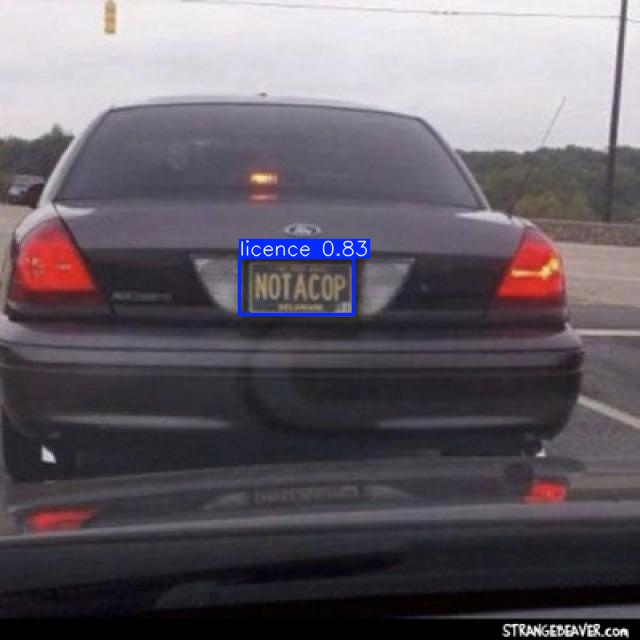

In [ ]:
from IPython.display import Image, display
import glob
import os

save_dir = str(results[0].save_dir)

predicted_images = glob.glob(save_dir + "/*.jpg") + glob.glob(save_dir + "/*.png")

display(Image(filename=predicted_images[0]))

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cartest.jpg to cartest.jpg


In [ ]:
uploaded_image = list(uploaded.keys())[0]

results = model.predict(
    source=uploaded_image,
    conf=0.25,
    save=True
)

print(results)


image 1/1 /content/cartest.jpg: 384x640 2 licences, 54.8ms
Speed: 2.6ms preprocess, 54.8ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'licence'}
obb: None
orig_img: array([[[ 18,  13,  12],
        [ 17,  12,  11],
        [ 17,  12,  11],
        ...,
        [219, 216, 212],
        [219, 216, 212],
        [219, 216, 212]],

       [[ 18,  13,  12],
        [ 17,  12,  11],
        [ 17,  12,  11],
        ...,
        [219, 216, 212],
        [219, 216, 212],
        [219, 216, 212]],

       [[ 18,  13,  12],
        [ 17,  12,  11],
        [ 17,  12,  11],
        ...,
        [219, 216, 212],
        [219, 216, 212],
        [219, 216, 212]],

       ...,

       [[125, 115, 115],
        [125, 115, 115],
        [125, 116, 113],
        ...,
        [117, 120, 124]

In [ ]:
from google.colab import files

files.download("/content/plate_detector.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>